In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

In [5]:
log_path = 'logs/train_log.csv' 
try:
    df = pd.read_csv(log_path)
    print("✅ Đã load dữ liệu thành công!")
    display(df.head())
except FileNotFoundError:
    print(f"❌ Không tìm thấy file tại {log_path}. Vui lòng kiểm tra lại đường dẫn.")

✅ Đã load dữ liệu thành công!


,Epoch,Train_Loss,Train_Acc,Val_Loss,Val_Acc,LR
0,1,0.5676,76.45,0.2496,84.96,0.001000
1,2,0.0527,96.65,0.1336,90.55,0.000997
2,3,0.0307,97.90,0.0692,95.31,0.000989
3,4,0.0237,98.50,0.0240,98.27,0.000976
4,5,0.0254,98.27,0.0189,98.43,0.000957


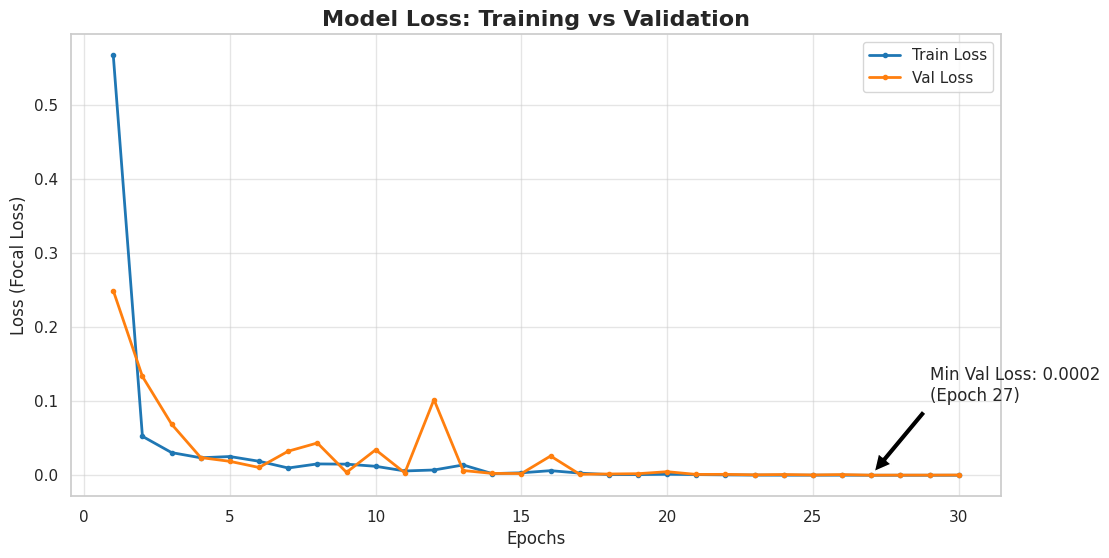

In [6]:
plt.figure(figsize=(12, 6))

# Vẽ đường Train Loss
plt.plot(df['Epoch'], df['Train_Loss'], label='Train Loss', marker='.', color='#1f77b4', linewidth=2)
# Vẽ đường Val Loss
plt.plot(df['Epoch'], df['Val_Loss'], label='Val Loss', marker='.', color='#ff7f0e', linewidth=2)

plt.title('Model Loss: Training vs Validation', fontsize=16, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss (Focal Loss)')
plt.legend()
plt.grid(True, alpha=0.5)

# Đánh dấu điểm Loss thấp nhất của Validation
min_loss_idx = df['Val_Loss'].idxmin()
min_loss = df.loc[min_loss_idx, 'Val_Loss']
best_epoch = df.loc[min_loss_idx, 'Epoch']

plt.annotate(f'Min Val Loss: {min_loss:.4f}\n(Epoch {best_epoch})',
             xy=(best_epoch, min_loss), xytext=(best_epoch+2, min_loss+0.1),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

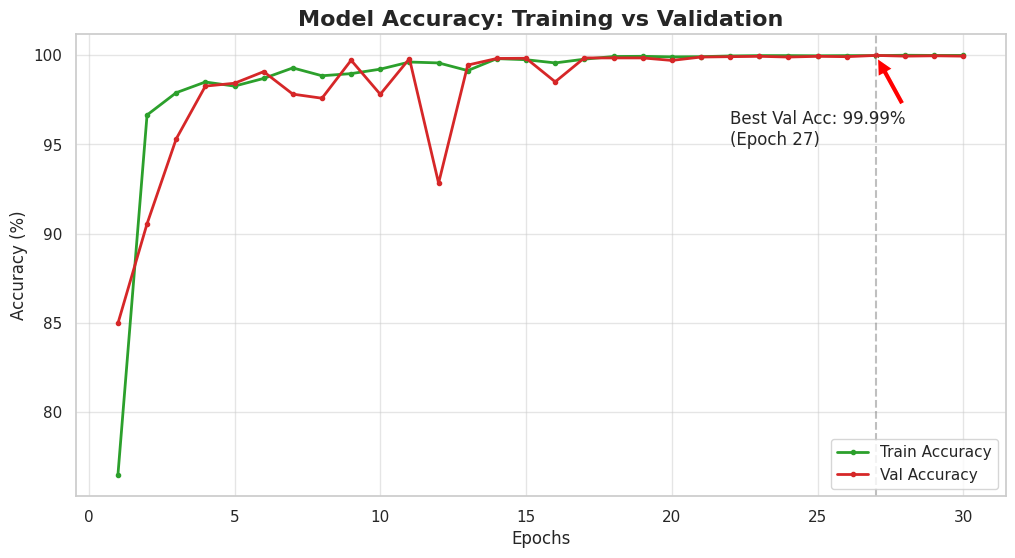

In [7]:
plt.figure(figsize=(12, 6))

# Vẽ đường Train Acc
plt.plot(df['Epoch'], df['Train_Acc'], label='Train Accuracy', marker='.', color='#2ca02c', linewidth=2)
# Vẽ đường Val Acc
plt.plot(df['Epoch'], df['Val_Acc'], label='Val Accuracy', marker='.', color='#d62728', linewidth=2)

plt.title('Model Accuracy: Training vs Validation', fontsize=16, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.5)

# Đánh dấu điểm Accuracy cao nhất
max_acc_idx = df['Val_Acc'].idxmax()
max_acc = df.loc[max_acc_idx, 'Val_Acc']
best_epoch_acc = df.loc[max_acc_idx, 'Epoch']

plt.axvline(x=best_epoch_acc, color='gray', linestyle='--', alpha=0.5)
plt.annotate(f'Best Val Acc: {max_acc:.2f}%\n(Epoch {best_epoch_acc})',
             xy=(best_epoch_acc, max_acc), xytext=(best_epoch_acc-5, max_acc-5),
             arrowprops=dict(facecolor='red', shrink=0.05))

plt.show()

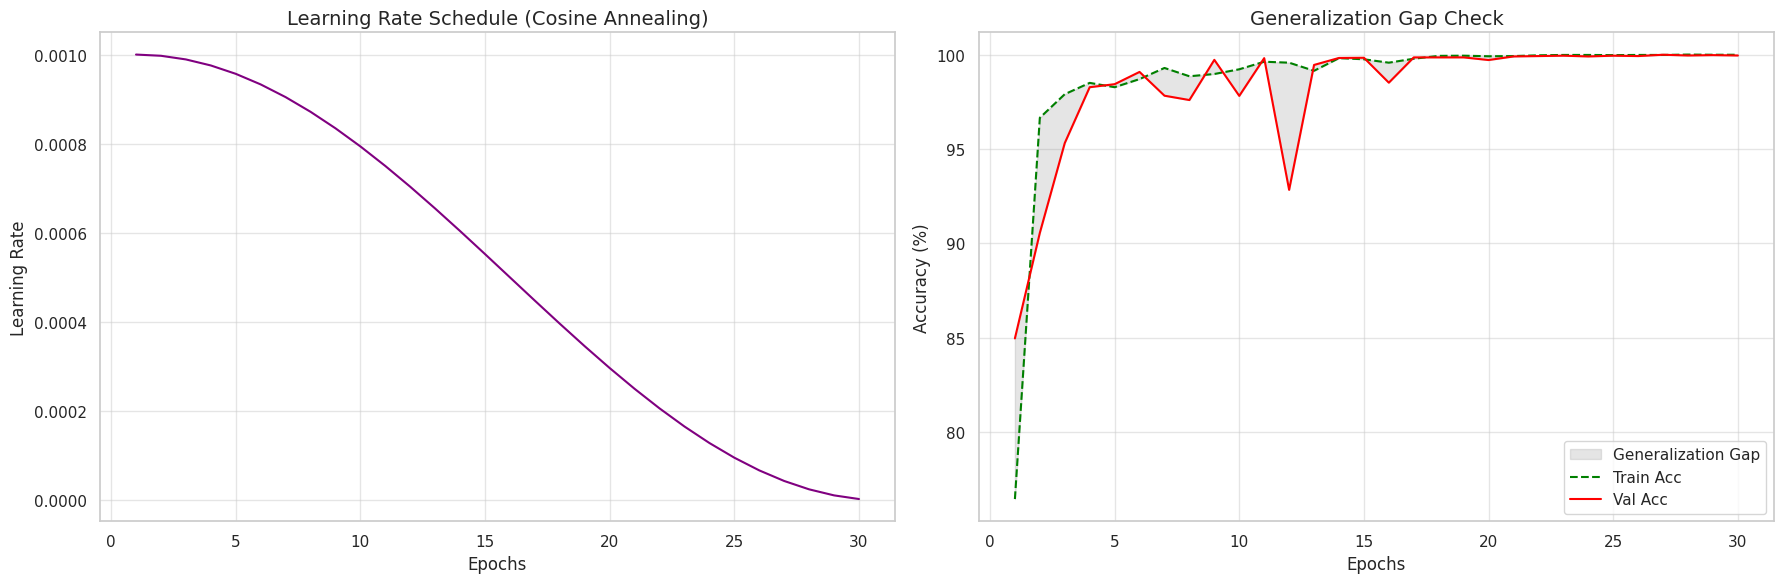

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# --- Biểu đồ 1: Learning Rate Schedule ---
ax1.plot(df['Epoch'], df['LR'], color='purple', linestyle='-')
ax1.set_title('Learning Rate Schedule (Cosine Annealing)', fontsize=14)
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Learning Rate')
ax1.grid(True, alpha=0.5)
# Có thể dùng scale log nếu LR thay đổi quá lớn
# ax1.set_yscale('log') 

# --- Biểu đồ 2: Overfitting Check (Train Acc - Val Acc) ---
gap = df['Train_Acc'] - df['Val_Acc']
ax2.fill_between(df['Epoch'], df['Train_Acc'], df['Val_Acc'], color='gray', alpha=0.2, label='Generalization Gap')
ax2.plot(df['Epoch'], df['Train_Acc'], label='Train Acc', linestyle='--', color='green')
ax2.plot(df['Epoch'], df['Val_Acc'], label='Val Acc', color='red')

ax2.set_title('Generalization Gap Check', fontsize=14)
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

✅ Đã tạo mapping thành công!
Kiểm tra lỗi: Model index 2 tương ứng với Class thực tế là 10 (Nếu là 10 thì đúng bệnh!)


/tmp/ipykernel_225388/635001047.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('checkpoints/resnet18_custom_best.pth', map_location=DEVICE)


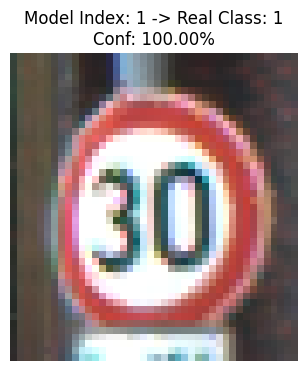

In [ ]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms, datasets
from PIL import Image
from src.resnet import ResNet18_Custom 
import os

# --- 1. TẠO MAPPING TỪ FOLDER TRAIN (QUAN TRỌNG) ---
# Model học theo thứ tự folder trong Train, ta phải lấy lại thứ tự đó
train_dir = 'data/Train' # Đảm bảo đường dẫn này đúng
temp_dataset = datasets.ImageFolder(root=train_dir)
class_to_idx = temp_dataset.class_to_idx # VD: {'0': 0, '1': 1, '10': 2...}

# Đảo ngược lại: Model ra số 2 -> Ta tra ra tên folder là "10"
idx_to_class = {v: int(k) for k, v in class_to_idx.items()}

print("✅ Đã tạo mapping thành công!")
print(f"Kiểm tra lỗi: Model index 2 tương ứng với Class thực tế là {idx_to_class[2]} (Nếu là 10 thì đúng bệnh!)")

# --- 2. CONFIG & LOAD MODEL ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Class tiền xử lý CLAHE
class ApplyCLAHE(object):
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size
    def __call__(self, img):
        img_np = np.array(img)
        lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=self.clip_limit, tileGridSize=self.tile_grid_size)
        l_eq = clahe.apply(l)
        lab_eq = cv2.merge((l_eq, a, b))
        rgb_eq = cv2.cvtColor(lab_eq, cv2.COLOR_LAB2RGB)
        return Image.fromarray(rgb_eq)

data_transform = transforms.Compose([
    transforms.Resize((48, 48)),
    ApplyCLAHE(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

model = ResNet18_Custom(num_classes=43).to(DEVICE)
checkpoint = torch.load('checkpoints/resnet18_custom_best.pth', map_location=DEVICE)

if isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
    state_dict = checkpoint['state_dict']
else:
    state_dict = checkpoint

new_state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
model.load_state_dict(new_state_dict)
model.eval()

# --- 3. DỰ ĐOÁN VỚI MAPPING MỚI ---
def predict_with_mapping(image_path):
    try:
        img = Image.open(image_path).convert('RGB')
    except:
        return

    img_tensor = data_transform(img).unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        confidence, pred_idx = torch.max(probs, 1)
        
    # --- BƯỚC MAP QUAN TRỌNG ---
    # pred_idx là số máy học (VD: 2) -> real_label là số người hiểu (VD: 10)
    real_label = idx_to_class[pred_idx.item()]
    
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"Model Index: {pred_idx.item()} -> Real Class: {real_label}\nConf: {confidence.item()*100:.2f}%")
    plt.axis('off')
    plt.show()

predict_with_mapping('data/Test/00005.png')

In [12]:
import pandas as pd
from torch.utils.data import Dataset, DataLoader

class TrafficTestDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.annotations = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, index):
        row = self.annotations.iloc[index]
        img_path = os.path.join(self.root_dir, row['Path']) 
        label = int(row['ClassId']) # Đây là Real Label (VD: 10)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label)

test_dataset = TrafficTestDataset('data/Test.csv', 'data', transform=data_transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

def evaluate_with_mapping(model, loader):
    model.eval()
    correct = 0
    total = 0
    all_real_preds = [] # Lưu label thực tế sau khi map
    all_true_labels = []
    
    print("⏳ Đang chạy đánh giá (Đang fix lỗi mapping)...")
    with torch.no_grad():
        for images, labels in loader: # labels ở đây là Real Label từ CSV
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            
            outputs = model(images)
            _, pred_indices = torch.max(outputs, 1)
            
            # --- MAP TỪNG BATCH ---
            # Chuyển tensor GPU -> list CPU -> map qua dict -> về lại tensor
            pred_indices_list = pred_indices.cpu().numpy()
            mapped_preds = [idx_to_class[idx] for idx in pred_indices_list]
            mapped_preds_tensor = torch.tensor(mapped_preds).to(DEVICE)
            
            total += labels.size(0)
            # So sánh Label sau khi map với Label từ CSV
            correct += (mapped_preds_tensor == labels).sum().item()
            
            all_real_preds.extend(mapped_preds)
            all_true_labels.extend(labels.cpu().numpy())
            
    acc = 100 * correct / total
    print(f'--- KẾT QUẢ ĐÃ FIX ---')
    print(f'Accuracy: {acc:.2f}%')
    return all_true_labels, all_real_preds

y_true, y_pred = evaluate_with_mapping(model, test_loader)

⏳ Đang chạy đánh giá (Đang fix lỗi mapping)...
--- KẾT QUẢ ĐÃ FIX ---
Accuracy: 98.78%


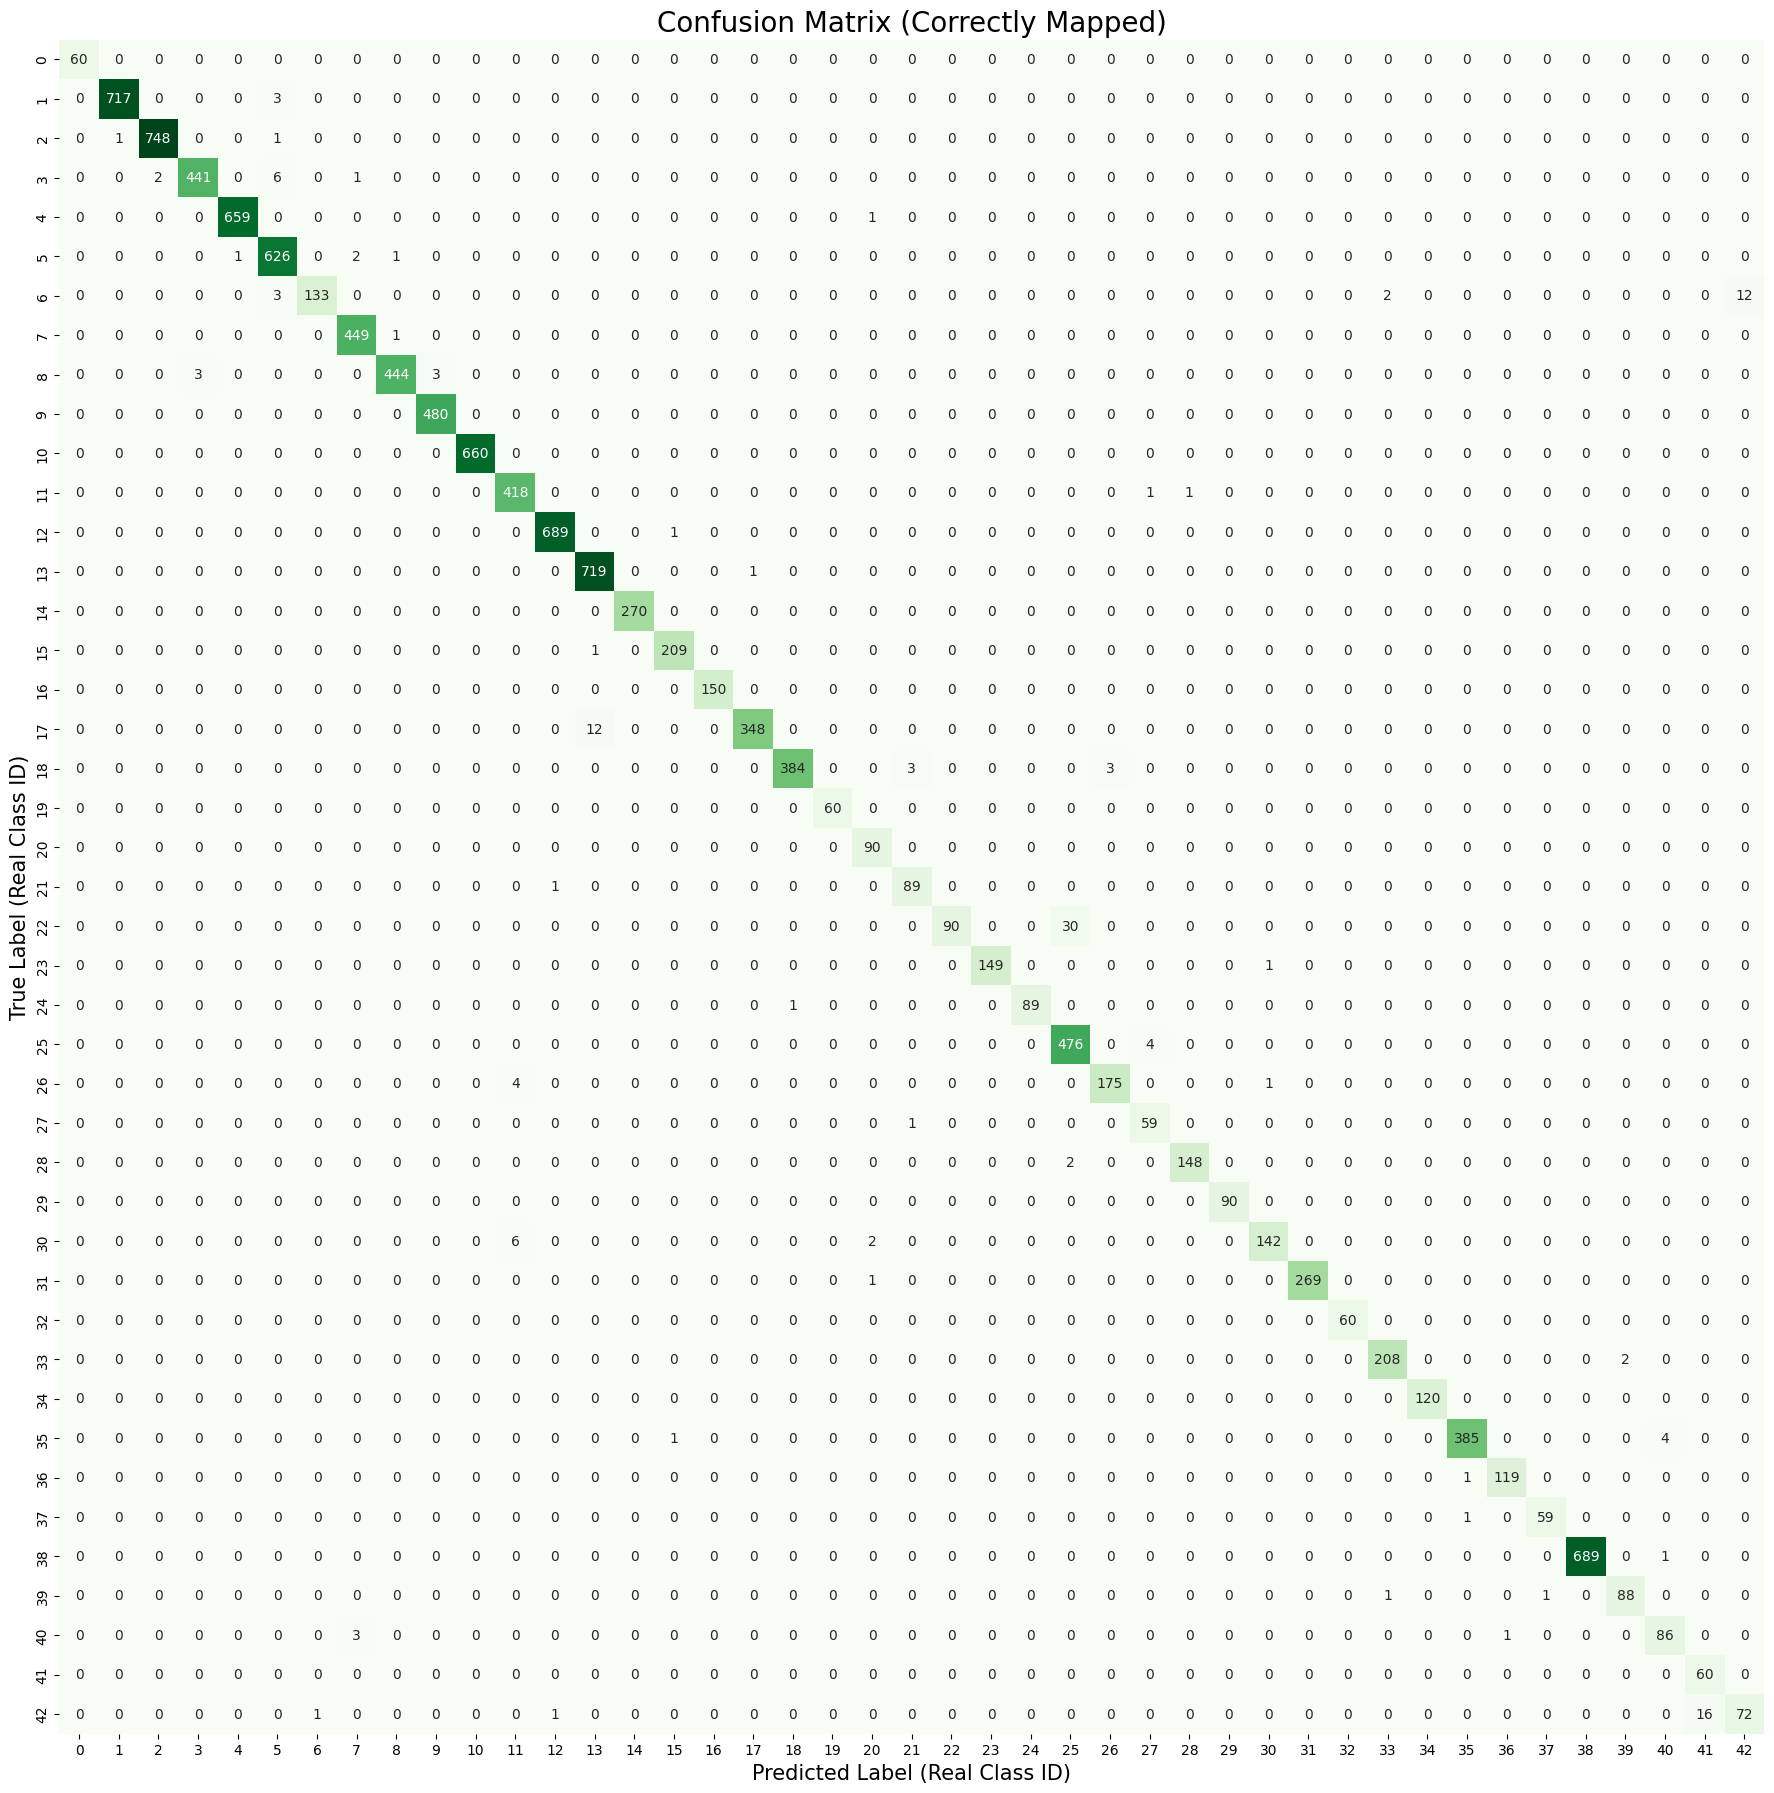

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       1.00      1.00      1.00       720
           2       1.00      1.00      1.00       750
           3       0.99      0.98      0.99       450
           4       1.00      1.00      1.00       660
           5       0.98      0.99      0.99       630
           6       0.99      0.89      0.94       150
           7       0.99      1.00      0.99       450
           8       1.00      0.99      0.99       450
           9       0.99      1.00      1.00       480
          10       1.00      1.00      1.00       660
          11       0.98      1.00      0.99       420
          12       1.00      1.00      1.00       690
          13       0.98      1.00      0.99       720
          14       1.00      1.00      1.00       270
          15       0.99      1.00      0.99       210
          16       1.00      1.00      1.00       150
          17       1.00    

In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(22, 22))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Confusion Matrix (Correctly Mapped)', fontsize=20)
plt.xlabel('Predicted Label (Real Class ID)', fontsize=15)
plt.ylabel('True Label (Real Class ID)', fontsize=15)
plt.show()

print(classification_report(y_true, y_pred))

In [14]:
# --- CELL DEBUGGING ---
def debug_model_behavior(model, loader):
    model.eval()
    all_preds = []
    
    print("Đang lấy mẫu dự đoán 1 batch đầu tiên...")
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            break # Chỉ chạy 1 batch để kiểm tra nhanh
            
    print(f"Sample Predictions (Batch đầu): {all_preds[:20]}")
    unique, counts = np.unique(all_preds, return_counts=True)
    print("\n--- PHÂN BỐ DỰ ĐOÁN ---")
    for u, c in zip(unique, counts):
        print(f"Class {u}: dự đoán {c} lần")
        
    if len(unique) == 1:
        print("\n=> CẢNH BÁO ĐỎ: Model bị 'Collapse'. Nó đang đoán toàn bộ ảnh là cùng 1 class!")
        print("Nguyên nhân: Training sai (Loss không giảm), hoặc Normalize sai lệch quá lớn.")
    else:
        print("\n=> Tốt: Model có đưa ra các dự đoán khác nhau.")

# Chạy debug
debug_model_behavior(model, test_loader)

Đang lấy mẫu dự đoán 1 batch đầu tiên...
Sample Predictions (Batch đầu): [np.int64(8), np.int64(1), np.int64(32), np.int64(27), np.int64(3), np.int64(32), np.int64(10), np.int64(4), np.int64(18), np.int64(29), np.int64(4), np.int64(40), np.int64(16), np.int64(40), np.int64(34), np.int64(42), np.int64(14), np.int64(13), np.int64(20), np.int64(32)]

--- PHÂN BỐ DỰ ĐOÁN ---
Class 1: dự đoán 2 lần
Class 2: dự đoán 3 lần
Class 3: dự đoán 3 lần
Class 4: dự đoán 4 lần
Class 5: dự đoán 3 lần
Class 7: dự đoán 1 lần
Class 8: dự đoán 3 lần
Class 9: dự đoán 2 lần
Class 10: dự đoán 3 lần
Class 12: dự đoán 1 lần
Class 13: dự đoán 1 lần
Class 14: dự đoán 1 lần
Class 16: dự đoán 2 lần
Class 17: dự đoán 1 lần
Class 18: dự đoán 2 lần
Class 19: dự đoán 1 lần
Class 20: dự đoán 2 lần
Class 23: dự đoán 3 lần
Class 24: dự đoán 1 lần
Class 27: dự đoán 2 lần
Class 28: dự đoán 1 lần
Class 29: dự đoán 2 lần
Class 32: dự đoán 4 lần
Class 34: dự đoán 3 lần
Class 38: dự đoán 2 lần
Class 40: dự đoán 3 lần
Class 41: 